# **📏📐 Feature Scaling**

- Scikit-learn Preprocessing
- https://scikit-learn.org/stable/api/sklearn.preprocessing.html
- Methods for scaling, centering, normalization, binarization, and more.

- Feature scaling is a crucial preprocessing step in machine learning that involves adjusting the range of values for different numerical features (variables) in your dataset.

- The goal is to ensure that each numerical feature contributes equally to the model, preventing some features from dominating others due to their larger scale.

- The feature scaling process is essential because many machine learning algorithms rely on distance metrics or gradient descent for optimisation, and having numerical features on different scales can lead to inefficiencies and suboptimal performance.

There are two primary methods of feature scaling:

- Normalization: This method rescales the data to fall within a specified range, typically between 0 and 1.

- Standardization: This method transforms the data so that it has a mean of zero and a standard deviation of one, effectively reshaping the data to follow a standard normal distribution.

| Scaler              | Handles Outliers? | Preserves Sparsity? | Output Range      | Suitable for   |
| ------------------- | ----------------- | ------------------- | ----------------- | -------------- |
| StandardScaler      | ❌                 | ❌                   | Centered around 0 | Most ML models |
| MinMaxScaler        | ❌                 | ❌                   | \[0, 1]           | NN, SVM        |
| RobustScaler        | ✅                 | ❌                   | Varies            | Outliers       |
| MaxAbsScaler        | ❌                 | ✅                   | \[-1, 1]          | Sparse data    |
| Normalizer          | ❌                 | ✅                   | Unit norm per row | k-NN, Cosine   |
| QuantileTransformer | ✅                 | ❌                   | Uniform or Normal | Skewed data    |
| PowerTransformer    | ✅                 | ❌                   | Gaussian-like     | Linear models  |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
np.random.seed(42)

In [3]:
# Sample dataset
X = pd.DataFrame({
    'income': [50000, 64000, 58000, 120000, 45000],
    'age': [25, 45, 35, 52, 23],
    'transactions': [1, 4, 2, 10, 3]
})

---
---
---
# **📊 Standardization**

- Standardization is a preprocessing technique used to transform the features of your data to have a mean of zero and a standard deviation of one.

- This process ensures that each feature contributes equally to the machine learning model by centering the data around the mean and scaling it by the standard deviation.

- Standardization is particularly useful for algorithms that assume normally distributed data.

---
---
# **✅ Standard Scaler**

- Z-score normalization
- Centers data to mean 0 and scales to unit variance

Use when:
- Data is approximately normal (bell-shaped).
- Models assume normality (e.g. Linear Regression, Logistic Regression, PCA, SVM).

Pros:

- Works well when data has similar scale and Gaussian distribution.

Cons: 

- Sensitive to outliers - extreme values distort the scale.

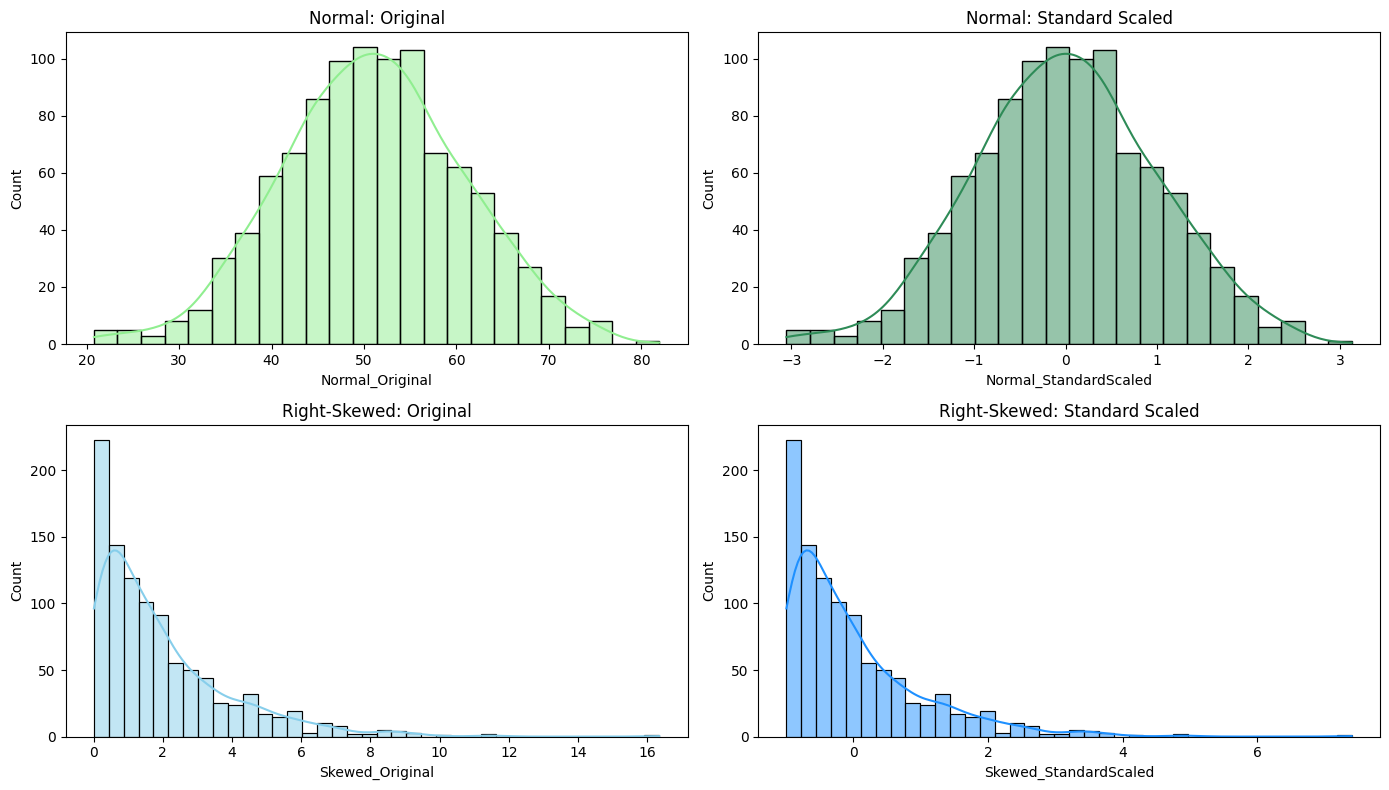

,Normal_Original,Normal_StandardScaled,Skewed_Original,Skewed_StandardScaled
0,51.777010,0.079727,0.938536,-0.517722
1,36.646556,-1.451016,6.020243,2.096262
2,53.801979,0.284592,2.633491,0.354148
3,56.105857,0.517675,1.825885,-0.061278
4,55.597904,0.466286,0.339250,-0.825989
5,60.807807,0.993370,0.339193,-0.826019
6,58.339222,0.743624,0.119678,-0.938935
7,54.591801,0.364498,4.022462,1.068621
8,49.298343,-0.171039,1.838164,-0.054961
9,33.390391,-1.780441,2.462500,0.266191


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# 1. Generate datasets and store in DataFrame
np.random.seed(42)
df = pd.DataFrame({
    "Skewed_Original": np.random.exponential(scale=2, size=1000),
    "Normal_Original": np.random.normal(loc=50, scale=10, size=1000)
})

# 2. Standard scale both columns
scaler = StandardScaler()
df["Normal_StandardScaled"] = scaler.fit_transform(df[["Normal_Original"]])
df["Skewed_StandardScaled"] = scaler.fit_transform(df[["Skewed_Original"]])

# 3. Reorder columns for better layout
df = df[[
    "Normal_Original", "Normal_StandardScaled",  # Nominal first
    "Skewed_Original", "Skewed_StandardScaled"   # Skewed next
]]

# 4. Plot histograms
fig, axs = plt.subplots(2, 2, figsize=(14, 8))

sns.histplot(df["Normal_Original"], kde=True, ax=axs[0, 0], color='lightgreen')
axs[0, 0].set_title("Normal: Original")

sns.histplot(df["Normal_StandardScaled"], kde=True, ax=axs[0, 1], color='seagreen')
axs[0, 1].set_title("Normal: Standard Scaled")

sns.histplot(df["Skewed_Original"], kde=True, ax=axs[1, 0], color='skyblue')
axs[1, 0].set_title("Right-Skewed: Original")

sns.histplot(df["Skewed_StandardScaled"], kde=True, ax=axs[1, 1], color='dodgerblue')
axs[1, 1].set_title("Right-Skewed: Standard Scaled")

plt.tight_layout()
plt.show()

# 5. Show first 10 rows
df.head(10)

---
---
---
# **🔑 Normalization**

- Scaling to a range

- Normalization is a preprocessing technique used to scale the features of your data so that they fall within a specific range, usually 0 to 1.

- This process ensures that no single feature dominates the others due to its scale, which can improve the performance of machine learning algorithms.

- The most common method for normalization is Min-Max normalization, which transforms each feature to a given range, typically [0, 1].

---
---
## **└─ MinMax Scaler**

- (Normalization to [0, 1])

- Use when: You need data between a specific range, e.g. in neural networks.

- Effect: Scales data to [0, 1].

- The normal data scales nicely into [0, 1].

- The version with outliers squashes the majority of the values into a narrow range (near 0), while outliers take up all the scale range.

- This distorts relationships between points — a small difference in original values becomes negligible after scaling.

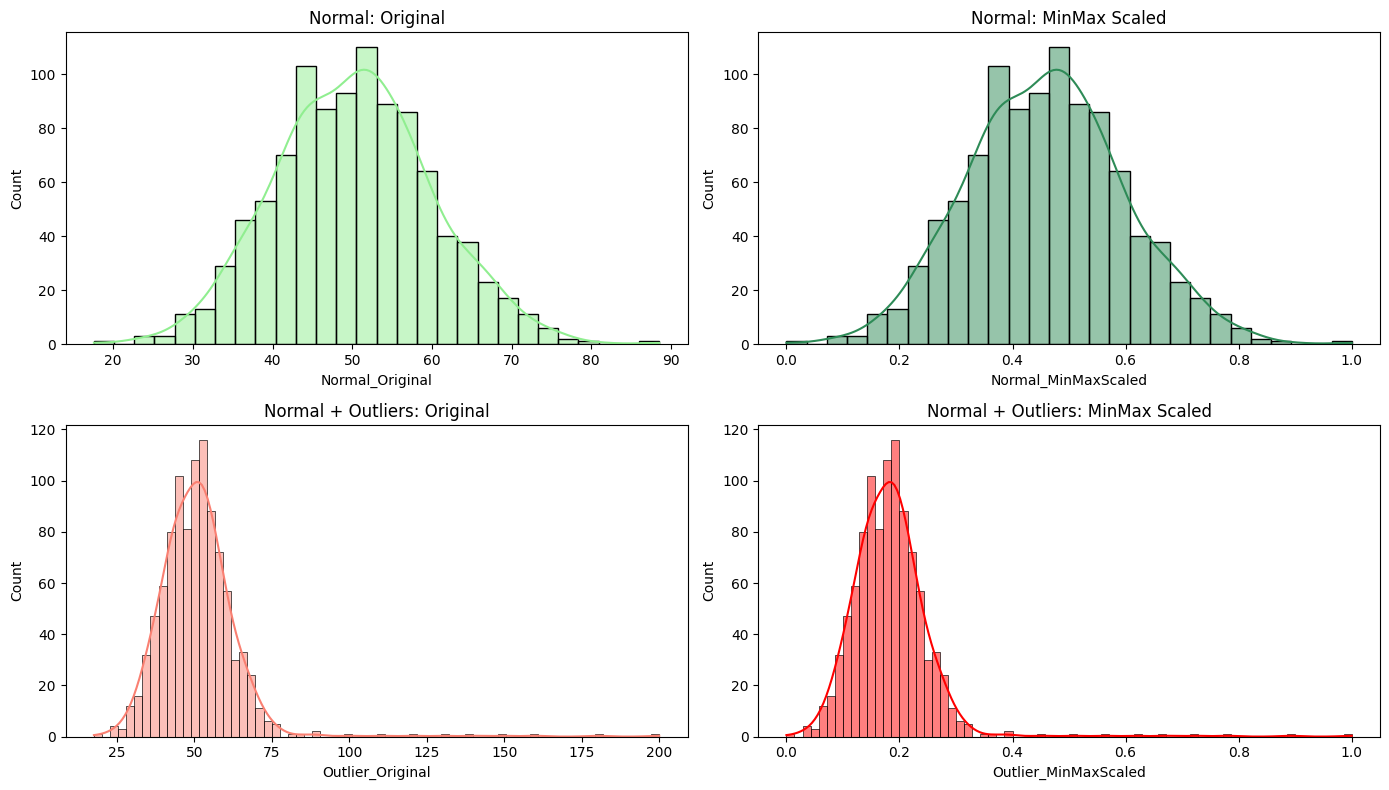

,Normal_Original,Normal_MinMaxScaled,Outlier_Original,Outlier_MinMaxScaled
0,54.967142,0.526922,200.0,1.000000
1,48.617357,0.437412,180.0,0.890358
2,56.476885,0.548204,160.0,0.780717
3,65.230299,0.671595,150.0,0.725896
4,47.658466,0.423895,140.0,0.671075
5,47.658630,0.423898,130.0,0.616255
6,65.792128,0.679515,120.0,0.561434
7,57.674347,0.565084,110.0,0.506613
8,45.305256,0.390724,100.0,0.451792
9,55.425600,0.533384,90.0,0.396972


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# 1. Generate dataset and store in DataFrame
np.random.seed(42)
df = pd.DataFrame({
    "Normal_Original": np.random.normal(loc=50, scale=10, size=1000)
})

# Inject outliers into a copy
df["Outlier_Original"] = df["Normal_Original"].copy()
df.loc[:10, "Outlier_Original"] = [200, 180, 160, 150, 140, 130, 120, 110, 100, 90, 85]  # 11 extreme values

# 2. MinMax scale both columns
scaler = MinMaxScaler()
df["Normal_MinMaxScaled"] = scaler.fit_transform(df[["Normal_Original"]])
df["Outlier_MinMaxScaled"] = scaler.fit_transform(df[["Outlier_Original"]])

# 3. Reorder columns for better layout
df = df[[
    "Normal_Original", "Normal_MinMaxScaled",  # Nominal first
    "Outlier_Original", "Outlier_MinMaxScaled"   # Outlier next
]]

# 4. Plot histograms to visualize
fig, axs = plt.subplots(2, 2, figsize=(14, 8))

sns.histplot(df["Normal_Original"], kde=True, ax=axs[0, 0], color='lightgreen')
axs[0, 0].set_title("Normal: Original")

sns.histplot(df["Normal_MinMaxScaled"], kde=True, ax=axs[0, 1], color='seagreen')
axs[0, 1].set_title("Normal: MinMax Scaled")

sns.histplot(df["Outlier_Original"], kde=True, ax=axs[1, 0], color='salmon')
axs[1, 0].set_title("Normal + Outliers: Original")

sns.histplot(df["Outlier_MinMaxScaled"], kde=True, ax=axs[1, 1], color='red')
axs[1, 1].set_title("Normal + Outliers: MinMax Scaled")

plt.tight_layout()
plt.show()

# 5. Preview first 10 rows (with outliers)
df.head(10)

---
---
## **└─ MaxAbs Scaler**

- (Preserves sparsity)

- Use when: Your data is sparse (many zeros) or you want to preserve sign and scale between -1 and 1.

- Effect: Divides by maximum absolute value per feature.

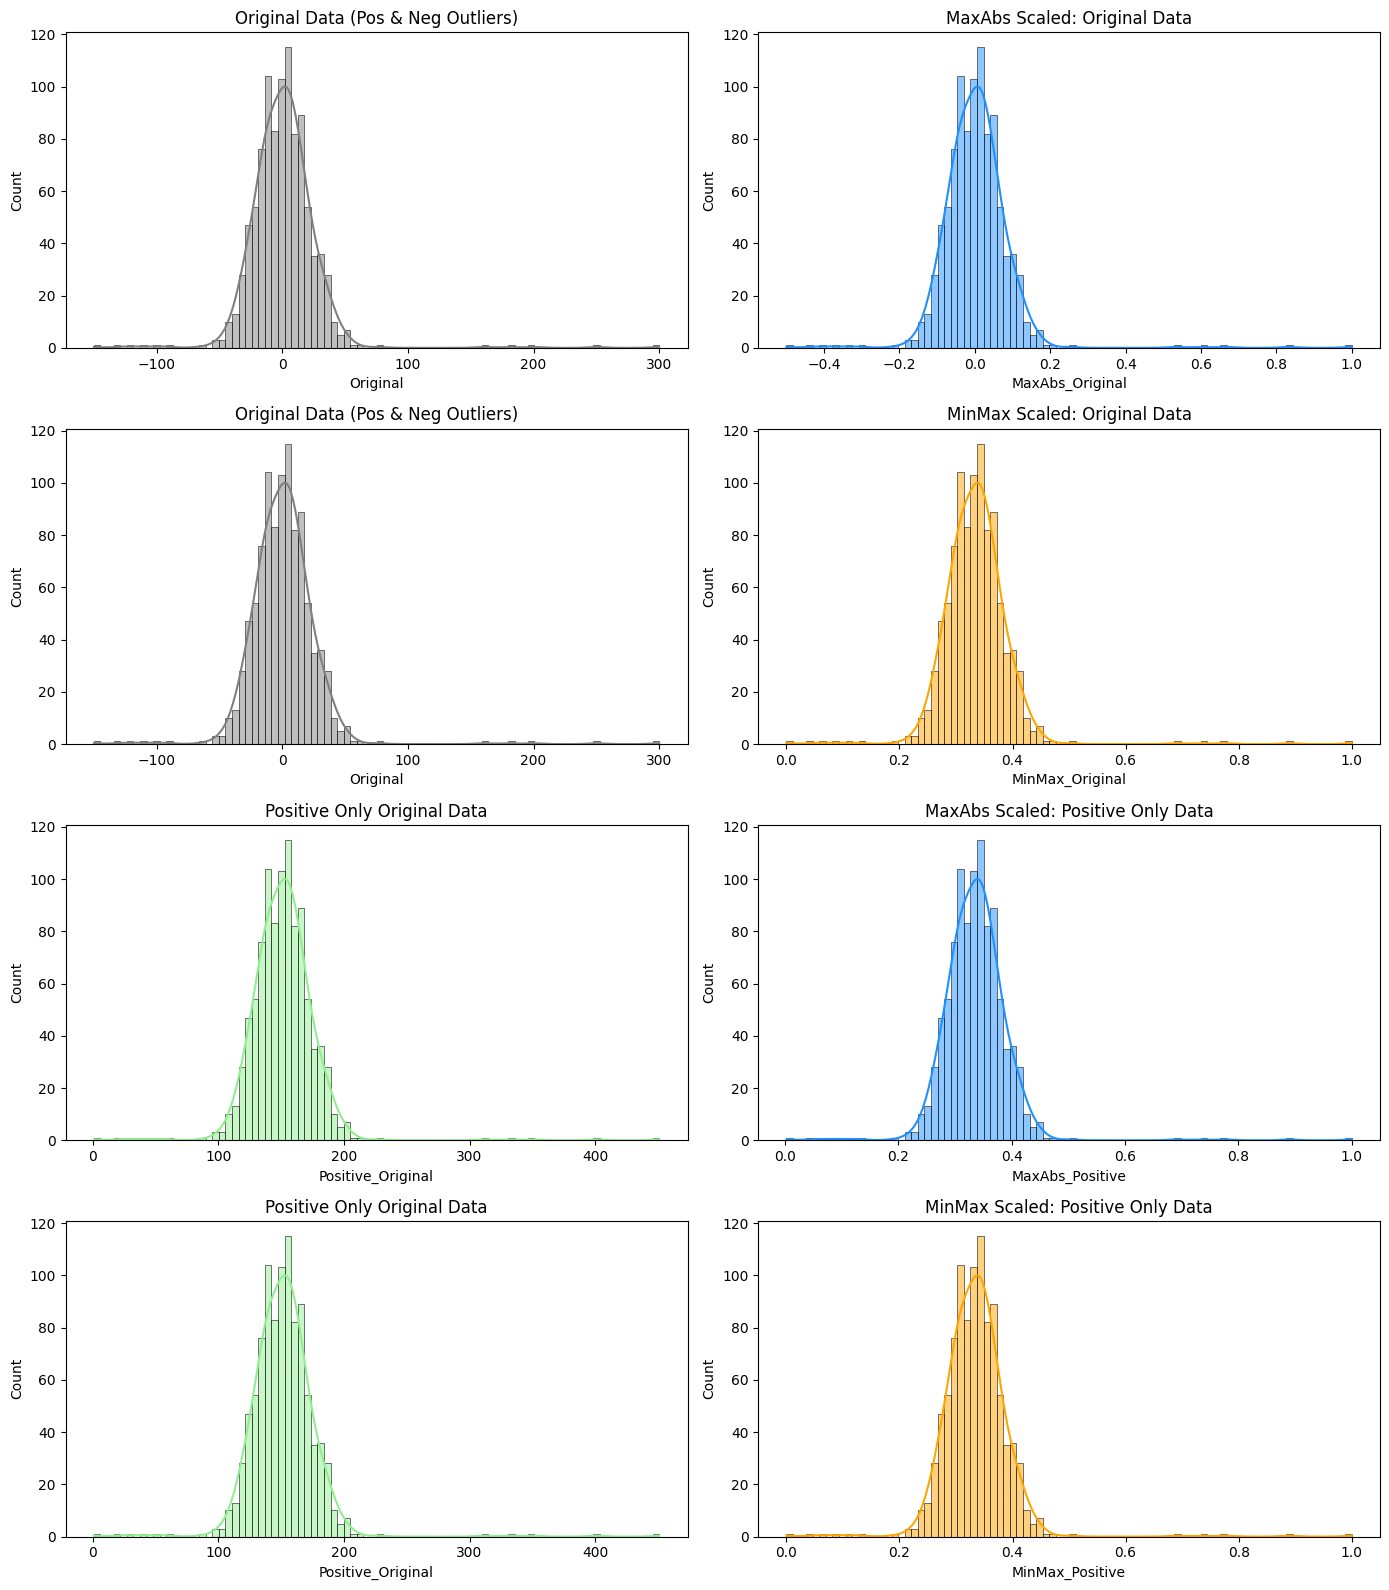

,Original,MaxAbs_Original,MinMax_Original,Positive_Original,MaxAbs_Positive,MinMax_Positive
0,300.0,1.000000,1.000000,451.0,1.000000,1.000000
1,250.0,0.833333,0.888889,401.0,0.889135,0.888889
2,200.0,0.666667,0.777778,351.0,0.778271,0.777778
3,180.0,0.600000,0.733333,331.0,0.733925,0.733333
4,160.0,0.533333,0.688889,311.0,0.689579,0.688889
5,-150.0,-0.500000,0.000000,1.0,0.002217,0.000000
6,-130.0,-0.433333,0.044444,21.0,0.046563,0.044444
7,-120.0,-0.400000,0.066667,31.0,0.068736,0.066667
8,-110.0,-0.366667,0.088889,41.0,0.090909,0.088889
9,-100.0,-0.333333,0.111111,51.0,0.113082,0.111111


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MaxAbsScaler, MinMaxScaler

# 1. Generate dataset with both positive and negative values
np.random.seed(42)
data = np.random.normal(loc=0, scale=20, size=1000)  # mean=0 for negatives too
df = pd.DataFrame({
    "Original": data
})

# Inject extreme positive and negative outliers
outliers = np.array([300, 250, 200, 180, 160, -150, -130, -120, -110, -100, -90])
df.loc[:10, "Original"] = outliers  # 11 outliers on both ends

# 2. Create positive-only version by shifting data up
min_val = df["Original"].min()
shift = abs(min_val) + 1  # shift to make all values positive and > 0
df["Positive_Original"] = df["Original"] + shift

# 3. Scale data using MaxAbsScaler and MinMaxScaler for both columns
maxabs_scaler = MaxAbsScaler()
minmax_scaler = MinMaxScaler()

df["MaxAbs_Original"] = maxabs_scaler.fit_transform(df[["Original"]])
df["MinMax_Original"] = minmax_scaler.fit_transform(df[["Original"]])

df["MaxAbs_Positive"] = maxabs_scaler.fit_transform(df[["Positive_Original"]])
df["MinMax_Positive"] = minmax_scaler.fit_transform(df[["Positive_Original"]])

# 4. Plot histograms
fig, axs = plt.subplots(4, 2, figsize=(14, 16))

sns.histplot(df["Original"], kde=True, ax=axs[0, 0], color='gray')
axs[0, 0].set_title("Original Data (Pos & Neg Outliers)")

sns.histplot(df["MaxAbs_Original"], kde=True, ax=axs[0, 1], color='dodgerblue')
axs[0, 1].set_title("MaxAbs Scaled: Original Data")

sns.histplot(df["Original"], kde=True, ax=axs[1, 0], color='gray')
axs[1, 0].set_title("Original Data (Pos & Neg Outliers)")

sns.histplot(df["MinMax_Original"], kde=True, ax=axs[1, 1], color='orange')
axs[1, 1].set_title("MinMax Scaled: Original Data")

sns.histplot(df["Positive_Original"], kde=True, ax=axs[2, 0], color='lightgreen')
axs[2, 0].set_title("Positive Only Original Data")

sns.histplot(df["MaxAbs_Positive"], kde=True, ax=axs[2, 1], color='dodgerblue')
axs[2, 1].set_title("MaxAbs Scaled: Positive Only Data")

sns.histplot(df["Positive_Original"], kde=True, ax=axs[3, 0], color='lightgreen')
axs[3, 0].set_title("Positive Only Original Data")

sns.histplot(df["MinMax_Positive"], kde=True, ax=axs[3, 1], color='orange')
axs[3, 1].set_title("MinMax Scaled: Positive Only Data")

plt.tight_layout()
plt.show()

# 5. Show first 10 rows for numeric comparison
df[[
    "Original", "MaxAbs_Original", "MinMax_Original",
    "Positive_Original", "MaxAbs_Positive", "MinMax_Positive"
]].head(10)


---
---
## **└─ Normalizer**

- (Normalize each row — not column)

- Use when: You care about direction but not magnitude, such as in text classification (TF-IDF) or k-NN.

- Effect: Row-wise vector normalization to unit norm.

In [7]:
from sklearn.preprocessing import Normalizer
scaler = Normalizer(norm='l2')  # or 'l1'
X_normalized = scaler.fit_transform(X)
print("Normalizer:\n", pd.DataFrame(X_normalized, columns=X.columns))

Normalizer:
    income       age  transactions
0     1.0  0.000500      0.000020
1     1.0  0.000703      0.000062
2     1.0  0.000603      0.000034
3     1.0  0.000433      0.000083
4     1.0  0.000511      0.000067


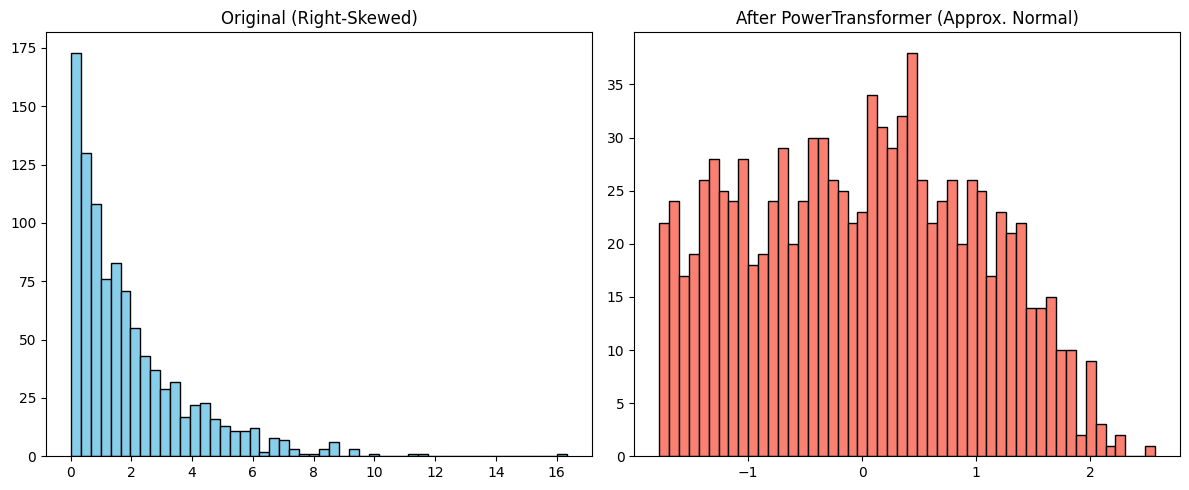

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer

# Generate a right-skewed distribution
np.random.seed(42)
data = np.random.exponential(scale=2, size=(1000, 1))

# Apply PowerTransformer (Yeo-Johnson by default)
pt = PowerTransformer(method='yeo-johnson')
data_transformed = pt.fit_transform(data)

# Plot before and after
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before
axes[0].hist(data, bins=50, color='skyblue', edgecolor='k')
axes[0].set_title("Original (Right-Skewed)")

# After
axes[1].hist(data_transformed, bins=50, color='salmon', edgecolor='k')
axes[1].set_title("After PowerTransformer (Approx. Normal)")

plt.tight_layout()
plt.show()

---
---
# **✅ Robust Scaler**

- (Robust to outliers)

- Use when: Data has many outliers.

- Effect: Centers using median and scales using IQR (interquartile range).

- Both scaled skewed distributions remain skewed. Neither scaler normalizes or symmetrizes the distribution — they only scale it.

- The heavy-tailed original data has big outliers that inflate the mean and std dev.

StandardScaler uses mean/std, so scaled data compresses most values near zero — losing resolution.

RobustScaler uses median/IQR, so scaled data keeps meaningful spread and reduces outlier impact.

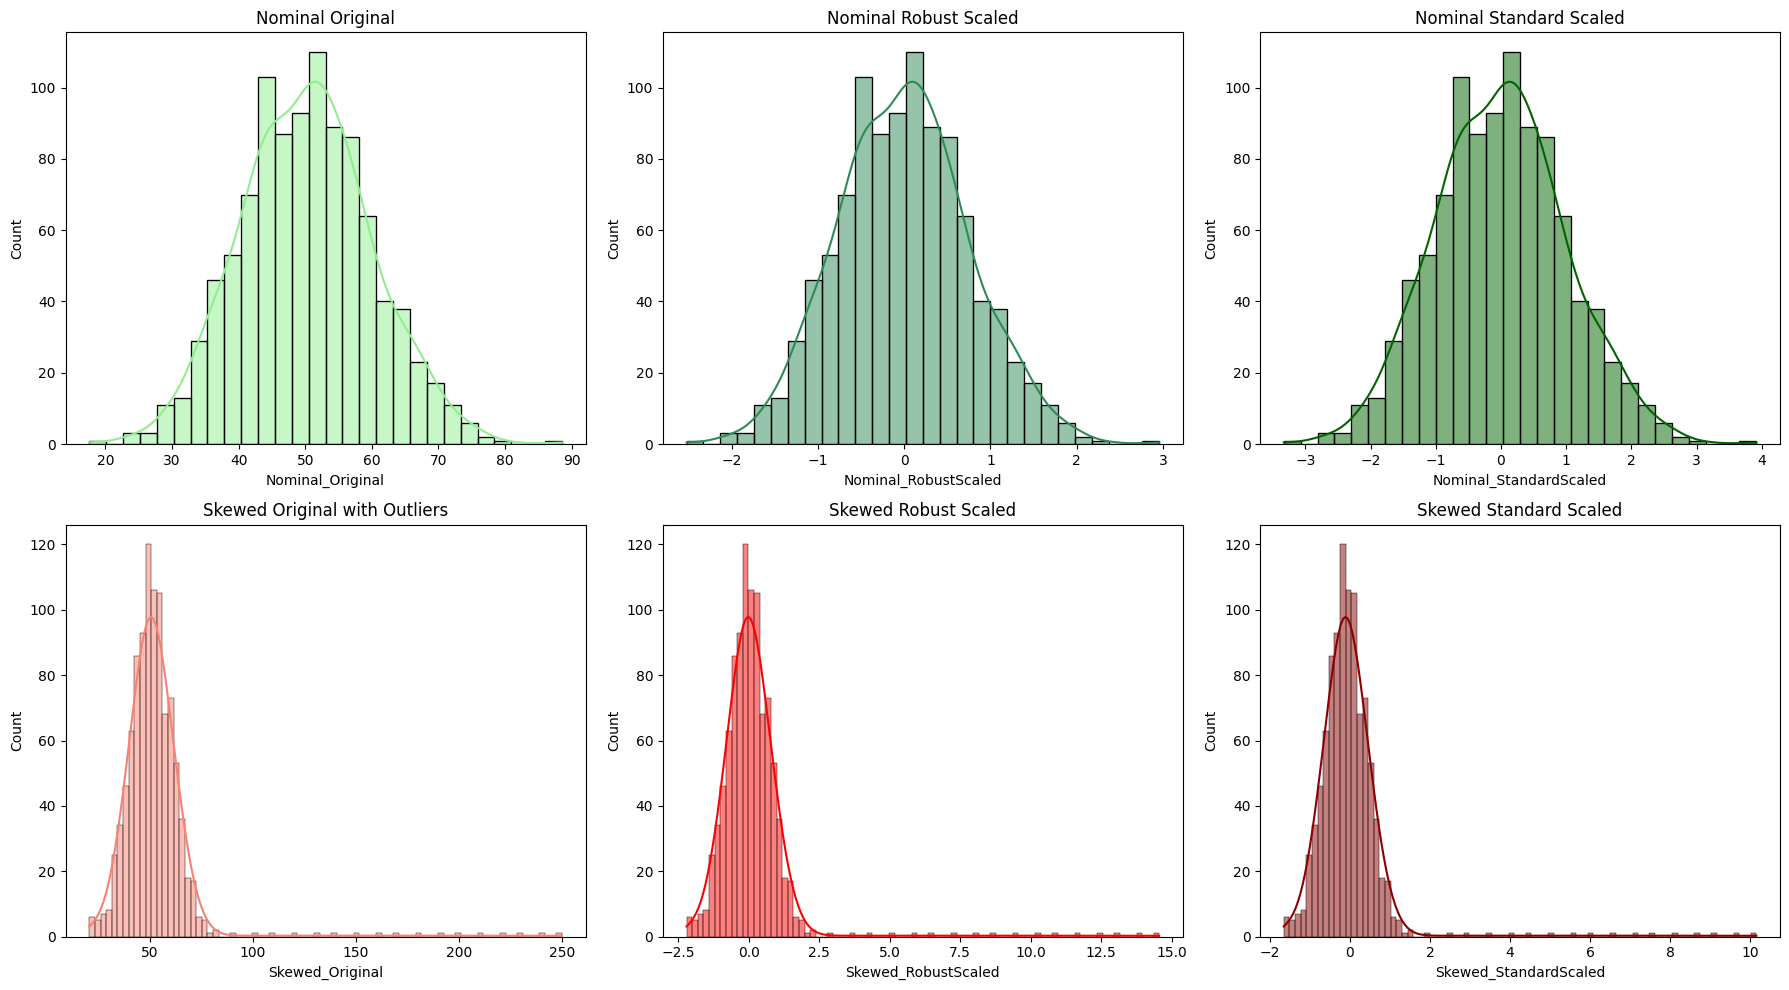

,Nominal_Original,Skewed_Original,Nominal_RobustScaled,Nominal_StandardScaled,Skewed_RobustScaled,Skewed_StandardScaled
0,54.967142,150.0,0.363876,0.487759,7.248139,5.004887
1,48.617357,140.0,-0.126253,-0.161022,6.517712,4.490396
2,56.476885,130.0,0.480410,0.642015,5.787286,3.975905
3,65.230299,120.0,1.156071,1.536382,5.056860,3.461414
4,47.658466,110.0,-0.200268,-0.258995,4.326434,2.946923
5,47.658630,100.0,-0.200255,-0.258978,3.596008,2.432432
6,65.792128,90.0,1.199437,1.593787,2.865581,1.917941
7,57.674347,80.0,0.572840,0.764364,2.135155,1.403449
8,45.305256,70.0,-0.381908,-0.499431,1.404729,0.888958
9,55.425600,60.0,0.399263,0.534601,0.674303,0.374467


In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler, StandardScaler

np.random.seed(42)

# 1. Generate nominal (normal) data and skewed with outliers
df = pd.DataFrame({
    "Nominal_Original": np.random.normal(loc=50, scale=10, size=1000)
})

# Add strong outliers to create a heavy-tailed distribution
skewed = np.random.normal(loc=50, scale=10, size=1000)
skewed[:20] = [150, 140, 130, 120, 110, 100, 90, 80, 70, 60,
               200, 190, 180, 170, 160, 210, 220, 230, 240, 250]
df["Skewed_Original"] = skewed

# 2. Scale using RobustScaler and StandardScaler
robust_scaler = RobustScaler()
standard_scaler = StandardScaler()

df["Nominal_RobustScaled"] = robust_scaler.fit_transform(df[["Nominal_Original"]])
df["Nominal_StandardScaled"] = standard_scaler.fit_transform(df[["Nominal_Original"]])

df["Skewed_RobustScaled"] = robust_scaler.fit_transform(df[["Skewed_Original"]])
df["Skewed_StandardScaled"] = standard_scaler.fit_transform(df[["Skewed_Original"]])

# 3. Plot distributions side by side for comparison
fig, axs = plt.subplots(2, 3, figsize=(18, 10))

# Nominal data
sns.histplot(df["Nominal_Original"], kde=True, ax=axs[0, 0], color='lightgreen')
axs[0, 0].set_title("Nominal Original")

sns.histplot(df["Nominal_RobustScaled"], kde=True, ax=axs[0, 1], color='seagreen')
axs[0, 1].set_title("Nominal Robust Scaled")

sns.histplot(df["Nominal_StandardScaled"], kde=True, ax=axs[0, 2], color='darkgreen')
axs[0, 2].set_title("Nominal Standard Scaled")

# Skewed data
sns.histplot(df["Skewed_Original"], kde=True, ax=axs[1, 0], color='salmon')
axs[1, 0].set_title("Skewed Original with Outliers")

sns.histplot(df["Skewed_RobustScaled"], kde=True, ax=axs[1, 1], color='red')
axs[1, 1].set_title("Skewed Robust Scaled")

sns.histplot(df["Skewed_StandardScaled"], kde=True, ax=axs[1, 2], color='darkred')
axs[1, 2].set_title("Skewed Standard Scaled")

plt.tight_layout()
plt.show()

# 4. Show first 10 rows to compare numeric values
df.head(10)

---
---
# **✅ Quantile Transformer**

- (Uniform or Gaussian output)

- Use when: Data is highly skewed or non-Gaussian.

- Effect: Non-linear transformation — maps data to uniform or normal distribution.

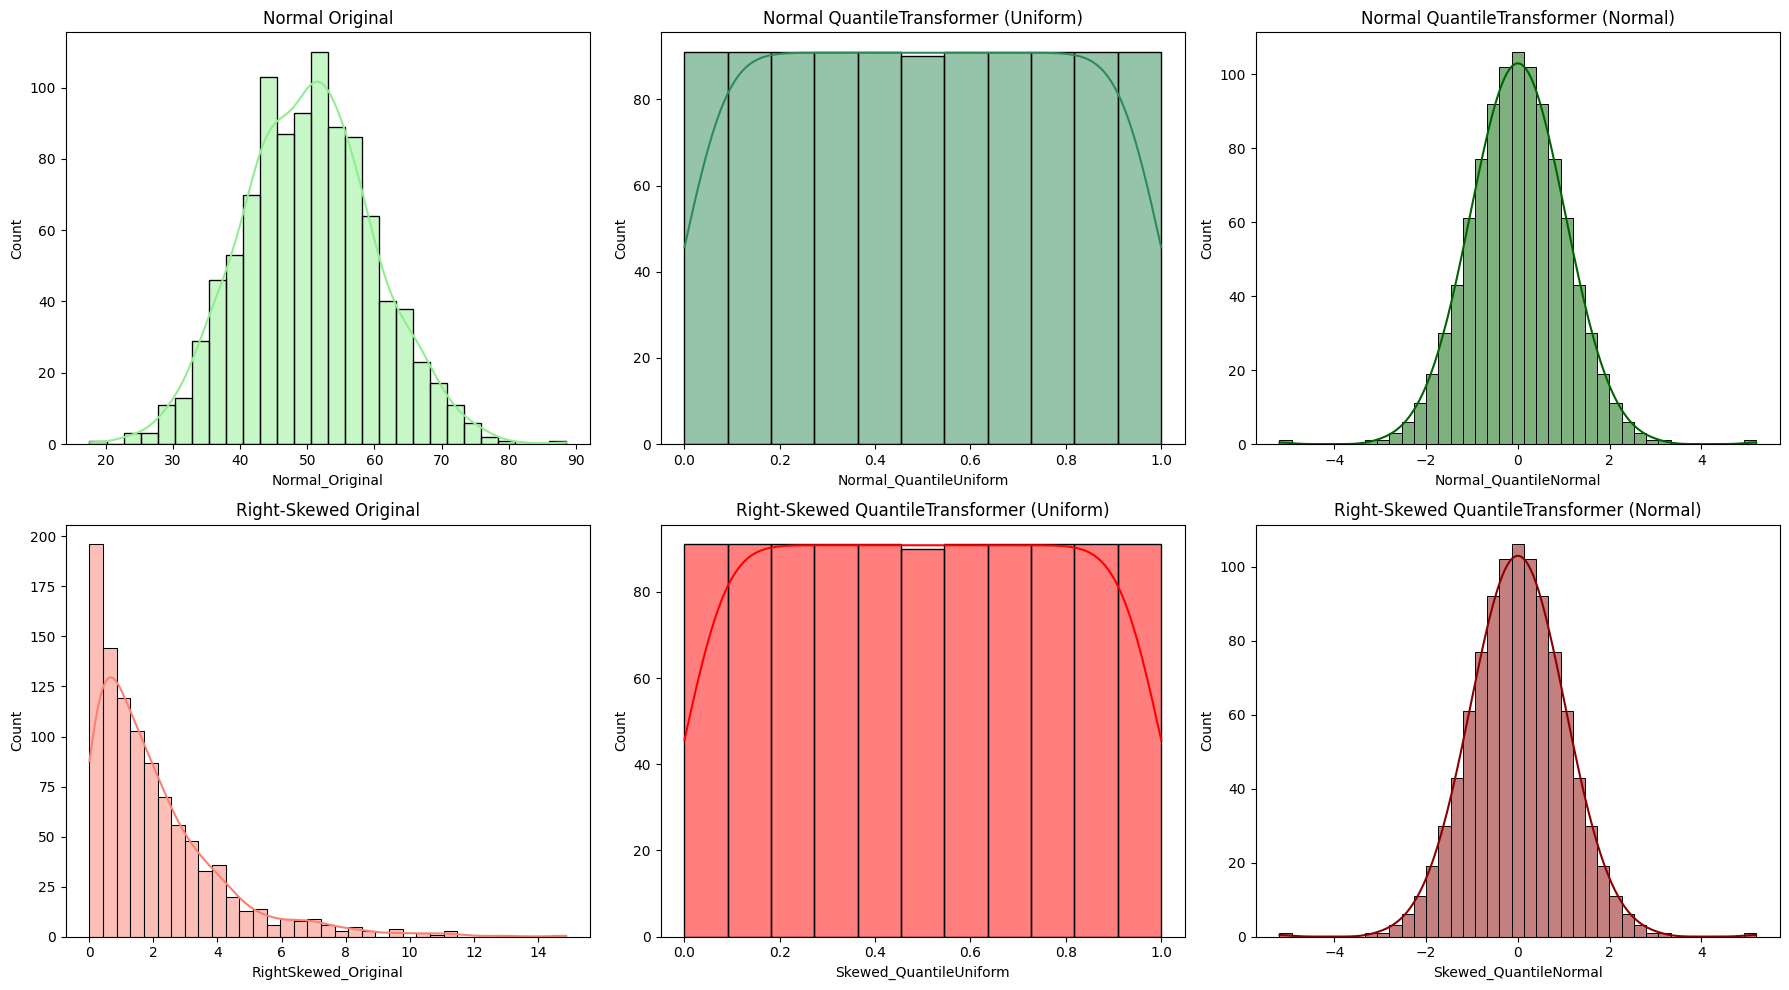

,Normal_Original,RightSkewed_Original,Normal_QuantileUniform,Normal_QuantileNormal,Skewed_QuantileUniform,Skewed_QuantileNormal
0,54.967142,0.366602,0.692693,0.503497,0.171171,-0.949547
1,48.617357,0.220898,0.435435,-0.162552,0.109109,-1.231280
2,56.476885,2.023568,0.749750,0.673702,0.625626,0.320290
3,65.230299,2.451590,0.928929,1.467860,0.702703,0.532190
4,47.658466,0.064191,0.404404,-0.241963,0.027027,-1.926403
5,47.658630,5.504388,0.405405,-0.239380,0.935936,1.521525
6,65.792128,0.106741,0.940941,1.562721,0.047047,-1.674186
7,57.674347,1.558702,0.789790,0.805692,0.531532,0.079120
8,45.305256,2.469280,0.325325,-0.452858,0.708709,0.549616
9,55.425600,4.095407,0.708709,0.549616,0.878879,1.169401


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import QuantileTransformer

np.random.seed(42)

# 1. Generate datasets
df = pd.DataFrame({
    "Normal_Original": np.random.normal(loc=50, scale=10, size=1000),
    "RightSkewed_Original": np.random.exponential(scale=2, size=1000)
})

# 2. Initialize QuantileTransformer
qt_uniform = QuantileTransformer(output_distribution='uniform', random_state=42)
qt_normal = QuantileTransformer(output_distribution='normal', random_state=42)

# 3. Apply QuantileTransformer on both datasets (normal and skewed)
df["Normal_QuantileUniform"] = qt_uniform.fit_transform(df[["Normal_Original"]])
df["Normal_QuantileNormal"] = qt_normal.fit_transform(df[["Normal_Original"]])

df["Skewed_QuantileUniform"] = qt_uniform.fit_transform(df[["RightSkewed_Original"]])
df["Skewed_QuantileNormal"] = qt_normal.fit_transform(df[["RightSkewed_Original"]])

# 4. Plot histograms and KDE for original vs transformed (3 columns × 2 rows)
fig, axs = plt.subplots(2, 3, figsize=(18, 10))

sns.histplot(df["Normal_Original"], kde=True, ax=axs[0,0], color='lightgreen')
axs[0,0].set_title("Normal Original")

sns.histplot(df["Normal_QuantileUniform"], kde=True, ax=axs[0,1], color='seagreen')
axs[0,1].set_title("Normal QuantileTransformer (Uniform)")

sns.histplot(df["Normal_QuantileNormal"], kde=True, ax=axs[0,2], color='darkgreen')
axs[0,2].set_title("Normal QuantileTransformer (Normal)")

sns.histplot(df["RightSkewed_Original"], kde=True, ax=axs[1,0], color='salmon')
axs[1,0].set_title("Right-Skewed Original")

sns.histplot(df["Skewed_QuantileUniform"], kde=True, ax=axs[1,1], color='red')
axs[1,1].set_title("Right-Skewed QuantileTransformer (Uniform)")

sns.histplot(df["Skewed_QuantileNormal"], kde=True, ax=axs[1,2], color='darkred')
axs[1,2].set_title("Right-Skewed QuantileTransformer (Normal)")

plt.tight_layout()
plt.show()

# 5. Preview first few rows
df.head(10)

--- Original ---
R² score: 0.9707
Coefficient: 2.9773
Intercept: 0.1478

--- StandardScaler ---
R² score: 0.9707
Coefficient: 5.8926
Intercept: 6.0502

--- QuantileTransformer ---
R² score: 0.7458
Coefficient: 5.2173
Intercept: 6.0502



c:\Users\joeln\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_data.py:2829: UserWarning: n_quantiles (1000) is greater than the total number of samples (800). n_quantiles is set to n_samples.
  warnings.warn(


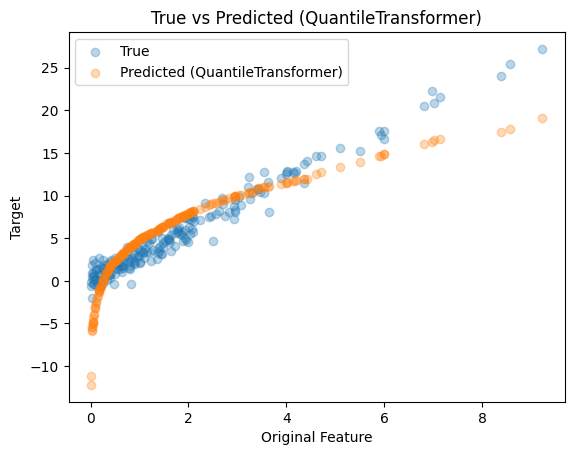

In [51]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

# 1. Generate skewed feature and target with linear relation + noise
n = 1000
X_skewed = np.random.exponential(scale=2, size=n).reshape(-1, 1)
# True relationship: y = 3*X + noise
y = 3 * X_skewed.flatten() + np.random.normal(0, 1, size=n)

# 2. Split data
X_train, X_test, y_train, y_test = train_test_split(X_skewed, y, test_size=0.2, random_state=42)

# 3. Prepare scalers and models
scalers = {
    "Original": None,
    "StandardScaler": StandardScaler(),
    "QuantileTransformer": QuantileTransformer(output_distribution='normal', random_state=42)
}

results = {}

for name, scaler in scalers.items():
    if scaler is not None:
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
    else:
        X_train_scaled, X_test_scaled = X_train, X_test
    
    model = LinearRegression()
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        "model": model,
        "r2_score": r2,
        "coef": model.coef_[0],
        "intercept": model.intercept_
    }

# 4. Display results
for name, res in results.items():
    print(f"--- {name} ---")
    print(f"R² score: {res['r2_score']:.4f}")
    print(f"Coefficient: {res['coef']:.4f}")
    print(f"Intercept: {res['intercept']:.4f}\n")

# 5. Plot true vs predicted for QuantileTransformer as example
model_qt = results["QuantileTransformer"]["model"]
X_test_qt = scalers["QuantileTransformer"].transform(X_test)

plt.scatter(X_test, y_test, alpha=0.3, label="True")
plt.scatter(X_test, model_qt.predict(X_test_qt), alpha=0.3, label="Predicted (QuantileTransformer)")
plt.xlabel("Original Feature")
plt.ylabel("Target")
plt.legend()
plt.title("True vs Predicted (QuantileTransformer)")
plt.show()

---
---
# **✅ Power Transformer**

- (Box-Cox or Yeo-Johnson)

- Use when: You want to make data more Gaussian-like, especially for linear models.

- Effect: Stabilizes variance and reduces skewness.

In [ ]:
from sklearn.preprocessing import PowerTransformer
scaler = PowerTransformer(method='yeo-johnson')  # use 'box-cox' for strictly positive data
X_power = scaler.fit_transform(X)
print("PowerTransformer:\n", pd.DataFrame(X_power, columns=X.columns))

PowerTransformer:
      income       age  transactions
0 -0.687326 -0.988445     -1.469125
1  0.394479  0.856713      0.427606
2  0.025823  0.063717     -0.533529
3  1.605864  1.315148      1.540447
4 -1.338843 -1.247134      0.034601


---
---
# **✅ Custom Transformer**


---
---
---